In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import gc
sns.set_theme()
gc.enable()

In [2]:
instalments_data=pd.read_csv('installments_payments.csv')
instalments_data.shape

(13605401, 8)

In [3]:
instalments_data.head()

,SK_ID_PREV,SK_ID_CURR,NUM_INSTALMENT_VERSION,NUM_INSTALMENT_NUMBER,DAYS_INSTALMENT,DAYS_ENTRY_PAYMENT,AMT_INSTALMENT,AMT_PAYMENT
0,1054186,161674,1.0,6,-1180.0,-1187.0,6948.360,6948.360
1,1330831,151639,0.0,34,-2156.0,-2156.0,1716.525,1716.525
2,2085231,193053,2.0,1,-63.0,-63.0,25425.000,25425.000
3,2452527,199697,1.0,3,-2418.0,-2426.0,24350.130,24350.130
4,2714724,167756,1.0,2,-1383.0,-1366.0,2165.040,2160.585


In [4]:
instalments_data.isnull().sum()

SK_ID_PREV                   0
SK_ID_CURR                   0
NUM_INSTALMENT_VERSION       0
NUM_INSTALMENT_NUMBER        0
DAYS_INSTALMENT              0
DAYS_ENTRY_PAYMENT        2905
AMT_INSTALMENT               0
AMT_PAYMENT               2905
dtype: int64

In [5]:
instalments_data.describe()

,SK_ID_PREV,SK_ID_CURR,NUM_INSTALMENT_VERSION,NUM_INSTALMENT_NUMBER,DAYS_INSTALMENT,DAYS_ENTRY_PAYMENT,AMT_INSTALMENT,AMT_PAYMENT
count,1.360540e+07,1.360540e+07,1.360540e+07,1.360540e+07,1.360540e+07,1.360250e+07,1.360540e+07,1.360250e+07
mean,1.903365e+06,2.784449e+05,8.566373e-01,1.887090e+01,-1.042270e+03,-1.051114e+03,1.705091e+04,1.723822e+04
std,5.362029e+05,1.027183e+05,1.035216e+00,2.666407e+01,8.009463e+02,8.005859e+02,5.057025e+04,5.473578e+04
min,1.000001e+06,1.000010e+05,0.000000e+00,1.000000e+00,-2.922000e+03,-4.921000e+03,0.000000e+00,0.000000e+00
25%,1.434191e+06,1.896390e+05,0.000000e+00,4.000000e+00,-1.654000e+03,-1.662000e+03,4.226085e+03,3.398265e+03
50%,1.896520e+06,2.786850e+05,1.000000e+00,8.000000e+00,-8.180000e+02,-8.270000e+02,8.884080e+03,8.125515e+03
75%,2.369094e+06,3.675300e+05,1.000000e+00,1.900000e+01,-3.610000e+02,-3.700000e+02,1.671021e+04,1.610842e+04
max,2.843499e+06,4.562550e+05,1.780000e+02,2.770000e+02,-1.000000e+00,-1.000000e+00,3.771488e+06,3.771488e+06


### Adding Some Columns

In [6]:
'''
DAYS_PAYMENT_DIFFERENCE: if positive means that those number of days late to payment. Otherwise, those number of
days prior to deadline.
LATE_PAYMENT: 0 if timely payment, 1 if late payment
AMT_PAYMENT_DIFFERENCE: if positive, it highlights how much less the customer paid.
AMT_PAYMENT_DIFFERENCE: pct difference wrt instalment amount
MISSED_PAYMENT: 0 is customer paid more than 10% of the amount. 1 otherwise
'''
instalments_data['DAYS_PAYMENT_DIFFERENCE']=instalments_data['DAYS_ENTRY_PAYMENT']-instalments_data['DAYS_INSTALMENT']

instalments_data['LATE_PAYMENT']=0
instalments_data.loc[instalments_data['DAYS_PAYMENT_DIFFERENCE']>0, 'LATE_PAYMENT']=1

instalments_data['AMT_PAYMENT_DIFFERENCE']=instalments_data['AMT_INSTALMENT']-instalments_data['AMT_PAYMENT']
instalments_data['AMT_PAYMENT_DIFFERENCE_PCT']=instalments_data['AMT_PAYMENT_DIFFERENCE']*100/instalments_data['AMT_INSTALMENT']

instalments_data['MISSSED_PAYMENT']=0
instalments_data.loc[instalments_data['AMT_PAYMENT_DIFFERENCE_PCT']>90, 'MISSED_PAYMENT']=1

In [7]:
'''
curr_prev_table stores the unique mapping of previous loans to current loans as a dataframe
'''
curr_prev_table=instalments_data[['SK_ID_CURR', 'SK_ID_PREV']].drop_duplicates()
curr_prev_table.shape

(997752, 2)

In [8]:
instalments_data.columns.sort_values()

Index(['AMT_INSTALMENT', 'AMT_PAYMENT', 'AMT_PAYMENT_DIFFERENCE',
       'AMT_PAYMENT_DIFFERENCE_PCT', 'DAYS_ENTRY_PAYMENT', 'DAYS_INSTALMENT',
       'DAYS_PAYMENT_DIFFERENCE', 'LATE_PAYMENT', 'MISSED_PAYMENT',
       'MISSSED_PAYMENT', 'NUM_INSTALMENT_NUMBER', 'NUM_INSTALMENT_VERSION',
       'SK_ID_CURR', 'SK_ID_PREV'],
      dtype='object')

### Aggregating based on SK_ID_PREV

In [9]:
'''
other features will be aggregate directly
'''
agg1=instalments_data.groupby(by='SK_ID_PREV').agg(func={'LATE_PAYMENT': 'sum', 'MISSED_PAYMENT': 'sum',
                                                         'SK_ID_PREV': 'count'})
agg1.rename(columns={'SK_ID_PREV': 'RECORDS'}, inplace=True)
agg1.reset_index(inplace=True)
agg1.head()

,SK_ID_PREV,LATE_PAYMENT,MISSED_PAYMENT,RECORDS
0,1000001,0,0.0,2
1,1000002,0,0.0,4
2,1000003,0,0.0,3
3,1000004,0,0.0,7
4,1000005,2,1.0,11


In [10]:
'''
adding some relevant columns
'''
agg1['LATE_PAYMENT_PCT']=agg1['LATE_PAYMENT']*100/agg1['RECORDS']
agg1['MISSED_PAYMENT_PCT']=agg1['MISSED_PAYMENT']*100/agg1['RECORDS']
agg1.shape

(997752, 6)

In [11]:
'''
adding the SK_ID_CURR
'''
agg1=pd.merge(left=curr_prev_table, right=agg1, on='SK_ID_PREV')

### Aggregating based on SK_ID_CURR

In [12]:
'''
aggregating remaining columns
'''
agg2=instalments_data.groupby(by='SK_ID_CURR').agg(func={'AMT_INSTALMENT': ['min', 'max', 'median'],
                                                    'AMT_PAYMENT_DIFFERENCE': ['min', 'max', 'median', 'sum'],
                                                    'AMT_PAYMENT_DIFFERENCE_PCT': ['min', 'max', 'median'],
                                                    'DAYS_INSTALMENT': ['min', 'max', 'median'],
                                                    'DAYS_PAYMENT_DIFFERENCE': ['min', 'max', 'median', 'sum']})

agg2.columns=pd.Index(['_'.join(val) for val in agg2.columns.to_flat_index()])
agg2.reset_index(inplace=True)
agg2.shape

(339587, 18)

In [13]:
'''
second level of aggregation for previously aggregated features (based on SK_ID_PREV)
'''
temp=agg1.groupby(by='SK_ID_CURR').agg({'LATE_PAYMENT': ['min', 'max', 'median', 'sum'],
                                   'MISSED_PAYMENT': ['min', 'max', 'median', 'sum'],
                                   'RECORDS': ['min', 'max', 'median', 'sum'],
                                   'LATE_PAYMENT_PCT': 'max', 'MISSED_PAYMENT_PCT': 'max', 'SK_ID_CURR': 'count'
                                   })

temp.columns=pd.Index(['_'.join(val) for val in temp.columns.to_flat_index()])
temp['LATE_PAYMENT_PCT']=temp['LATE_PAYMENT_sum']*100/temp['RECORDS_sum']
temp['MISSED_PAYMENT_PCT']=temp['MISSED_PAYMENT_sum']*100/temp['RECORDS_sum']
temp.reset_index(inplace=True)
temp.shape

(339587, 18)

In [14]:
'''
merging both datsets
'''
agg2=pd.merge(left=agg2, right=temp, on='SK_ID_CURR')
agg2.shape

(339587, 35)

In [15]:
'''
adding target column
<main_data_id_target> contains target for each current loan
'''
main_data_id_target=pd.read_csv('application_train.csv',usecols=['SK_ID_CURR', 'TARGET']) 
agg_target=pd.merge(left=agg2, right=main_data_id_target, on='SK_ID_CURR')
agg_target.shape

(291643, 36)

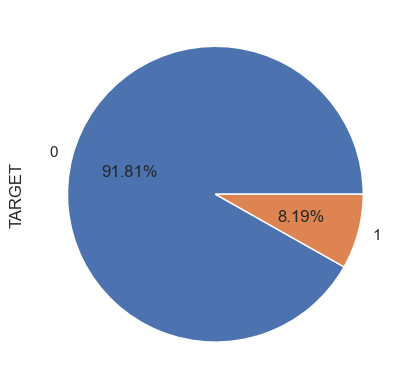

In [16]:
'''
distribution of target in the aggregated bureau data
'''
agg_target['TARGET'].value_counts().plot.pie(autopct='%1.2f%%');

In [17]:
agg_target.isnull().sum()

SK_ID_CURR                           0
AMT_INSTALMENT_min                   0
AMT_INSTALMENT_max                   0
AMT_INSTALMENT_median                0
AMT_PAYMENT_DIFFERENCE_min           8
AMT_PAYMENT_DIFFERENCE_max           8
AMT_PAYMENT_DIFFERENCE_median        8
AMT_PAYMENT_DIFFERENCE_sum           0
AMT_PAYMENT_DIFFERENCE_PCT_min       8
AMT_PAYMENT_DIFFERENCE_PCT_max       8
AMT_PAYMENT_DIFFERENCE_PCT_median    8
DAYS_INSTALMENT_min                  0
DAYS_INSTALMENT_max                  0
DAYS_INSTALMENT_median               0
DAYS_PAYMENT_DIFFERENCE_min          8
DAYS_PAYMENT_DIFFERENCE_max          8
DAYS_PAYMENT_DIFFERENCE_median       8
DAYS_PAYMENT_DIFFERENCE_sum          0
LATE_PAYMENT_min                     0
LATE_PAYMENT_max                     0
LATE_PAYMENT_median                  0
LATE_PAYMENT_sum                     0
MISSED_PAYMENT_min                   0
MISSED_PAYMENT_max                   0
MISSED_PAYMENT_median                0
MISSED_PAYMENT_sum       

### Functions

In [18]:
def plot_hist_box(data, feature):
    '''
    takes dataframe and a feature name, outputs a plot with boxplot and histogram of the feature
    '''
    fig, axes=plt.subplots(ncols=2)
    fig.set_size_inches(w=10, h=5)
    axes[0].boxplot(data[feature].dropna());
    axes[0].set_xticklabels([feature]);
    axes[1].hist(data[feature]);
    return axes

In [19]:
def plot_hist_default_pct(feature, dataframe, bins):
    '''
    takes a dataframe, a feature name and number of bins. Plots a histogram of the feature such that binning is equal width, and the value is the deafult percentage of that bin.  
    '''
    df=dataframe.copy()
    df['%s_binned'%feature]=pd.qcut(df[feature], q=bins, precision=3, duplicates='drop')
    counts=df['%s_binned'%feature].value_counts()
    default_counts=df.loc[df['TARGET']==1, '%s_binned'%feature].value_counts()
    default_counts=default_counts*100/counts
    default_counts.sort_index(inplace=True)
    ax=plt.axes()
    ax.bar(default_counts.index.astype(str), default_counts.values)
    ax.tick_params(axis='x', rotation=90)
    ax.set_title('Deafulters %% in %s'%feature)
    ax.set_xlabel('Category')
    ax.set_ylabel('Defaulter %')
    print(default_counts)


In [20]:
def calc_iqr(feature, data):
    '''
    takes a dataframe and a feature name, returns the the 1st quartile, 3rd quartile and the inter-quartile range
    '''
    q3=data[feature].quantile(0.75)
    q1=data[feature].quantile(0.25)
    iqr=q3-q1
    return q1, q3, iqr

In [21]:
def plot_kde_vs_target(feature, main_data):
    '''
    takes a dataframe and a feature name, plots two kernel density plots, one for deafulter customers and other of non-deafulter customers. plots nothing of the variance of the feature is zero. 
    '''
    paid=main_data[main_data['TARGET']==0][feature]
    defaulted=main_data[main_data['TARGET']==1][feature]
    sns.kdeplot(paid, label='Paid', color='b')
    sns.kdeplot(defaulted, label='Defaulted', color='r')
    plt.legend()

In [22]:
def plot_all_numeric_kde(main_data, numerical_features):
    '''
    takes a dataframe and an index of feature names, plots the kernel density plots of all features present in numerical_features   
    '''
    fig, axes=plt.subplots(numerical_features.shape[0])
    fig.set_size_inches(10, 4*numerical_features.shape[0])
    for i, feature in enumerate(numerical_features):
        q1, q3, iqr=calc_iqr(feature, main_data)
        plot_data=main_data.loc[(main_data[feature]>=q1-1.5*iqr) & (main_data[feature]<=q3+1.5*iqr), :]
        paid=plot_data[plot_data['TARGET']==0][feature]
        defaulted=plot_data[plot_data['TARGET']==1][feature]
        sns.kdeplot(paid, label='Paid', color='b', ax=axes[i])
        sns.kdeplot(defaulted, label='Defaulted', color='r', ax=axes[i])
        axes[i].legend()

In [23]:
def plot_pie_target(target_series, ax=None):
    if ax is None:
        ax=plt.axes()
    plot_data=target_series.value_counts()
    plot_data.rename(index={0: "Paid", 1: "Defaulted"}, inplace=True)
    ax.pie(x=plot_data.values, labels=plot_data.index, autopct='%1.1f%%')
    return ax



In [24]:
def median_vs_target(feature, data):
    '''
    takes a feature name and a dataframe. prints two values, one is median of non-defaulters while other is median of deafulters
    '''
    print('Median of %s with target=0 : %f'%(feature, data.loc[data['TARGET']==0, feature].median()))
    print('Median of %s with target=1 : %f'%(feature, data.loc[data['TARGET']==1, feature].median()))

In [25]:
# plot_all_numeric_kde(agg_target, agg_target.columns)

In [26]:
numerical_features=pd.Index(['SK_ID_CURR', 'TARGET', 'AMT_INSTALMENT_median', 'AMT_PAYMENT_DIFFERENCE_max',
                             'AMT_PAYMENT_DIFFERENCE_sum', 'AMT_PAYMENT_DIFFERENCE_PCT_max',
                             'DAYS_INSTALMENT_min', 'DAYS_INSTALMENT_median', 'DAYS_PAYMENT_DIFFERENCE_max',
                             'DAYS_PAYMENT_DIFFERENCE_median', 'DAYS_PAYMENT_DIFFERENCE_sum', 
                             'LATE_PAYMENT_sum', 'MISSED_PAYMENT_sum', 'RECORDS_min',
                             'RECORDS_median', 'LATE_PAYMENT_PCT_max'])
numerical_frame=agg_target[numerical_features].copy()
numerical_frame.shape, numerical_frame.columns.sort_values()

((291643, 16),
 Index(['AMT_INSTALMENT_median', 'AMT_PAYMENT_DIFFERENCE_PCT_max',
        'AMT_PAYMENT_DIFFERENCE_max', 'AMT_PAYMENT_DIFFERENCE_sum',
        'DAYS_INSTALMENT_median', 'DAYS_INSTALMENT_min',
        'DAYS_PAYMENT_DIFFERENCE_max', 'DAYS_PAYMENT_DIFFERENCE_median',
        'DAYS_PAYMENT_DIFFERENCE_sum', 'LATE_PAYMENT_PCT_max',
        'LATE_PAYMENT_sum', 'MISSED_PAYMENT_sum', 'RECORDS_median',
        'RECORDS_min', 'SK_ID_CURR', 'TARGET'],
       dtype='object'))

### AMT_INSTALMENT_median

In [27]:
numerical_frame['AMT_INSTALMENT_median'].isnull().sum()

0

In [28]:
numerical_frame['AMT_INSTALMENT_median'].describe()

count    2.916430e+05
mean     1.278459e+04
std      1.730855e+04
min      0.000000e+00
25%      5.790398e+03
50%      9.358290e+03
75%      1.527030e+04
max      2.504590e+06
Name: AMT_INSTALMENT_median, dtype: float64

array([<Axes: >, <Axes: >], dtype=object)

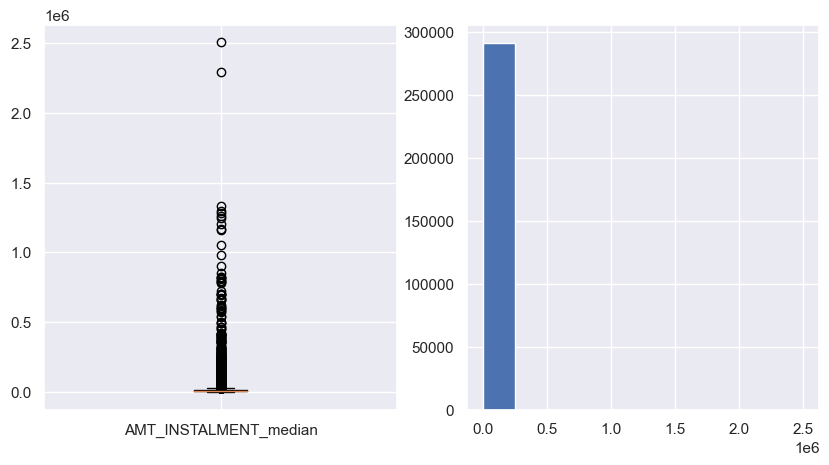

In [29]:
plot_hist_box(numerical_frame, 'AMT_INSTALMENT_median')

Number of outliers : 527


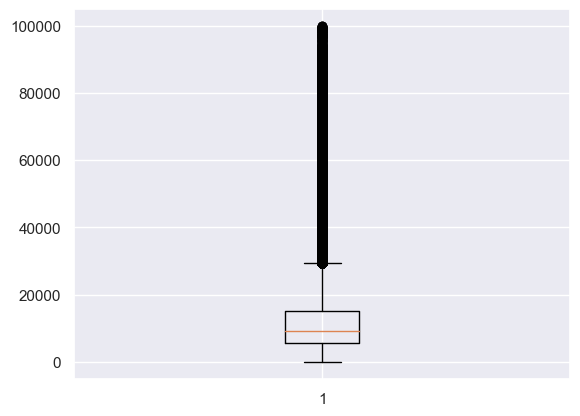

In [30]:
'''
this cell adjusts the outlier range, marks outlier records (nans remain unchanged), and also scales the data to year scale.
'''

plt.boxplot(numerical_frame.loc[numerical_frame['AMT_INSTALMENT_median']<0.1e6, 'AMT_INSTALMENT_median']);
numerical_frame['AMT_INSTALMENT_median_outlier']=0
numerical_frame.loc[numerical_frame['AMT_INSTALMENT_median']>=0.1e6, 'AMT_INSTALMENT_median_outlier']=1
good_frame=numerical_frame.loc[numerical_frame['AMT_INSTALMENT_median_outlier']==0, :]
print('Number of outliers : %d'%((numerical_frame['AMT_INSTALMENT_median_outlier']==1).sum()))

array([<Axes: >, <Axes: >], dtype=object)

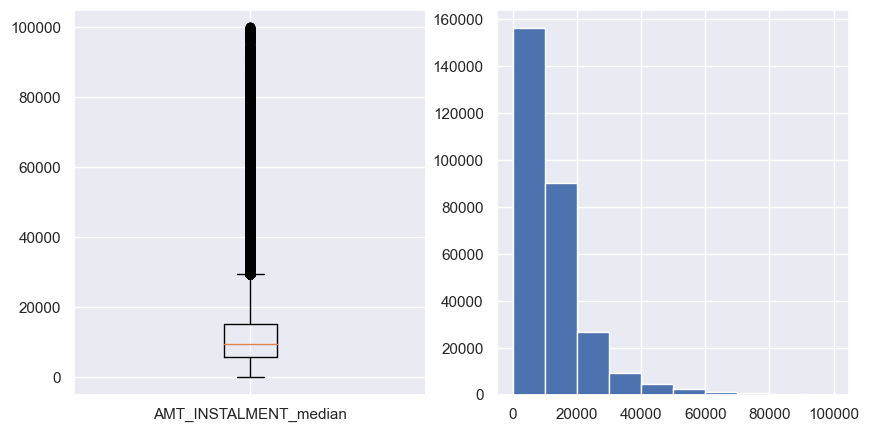

In [31]:
plot_hist_box(good_frame, 'AMT_INSTALMENT_median')

Median of AMT_INSTALMENT_median with target=0 : 9426.240000
Median of AMT_INSTALMENT_median with target=1 : 8551.890000


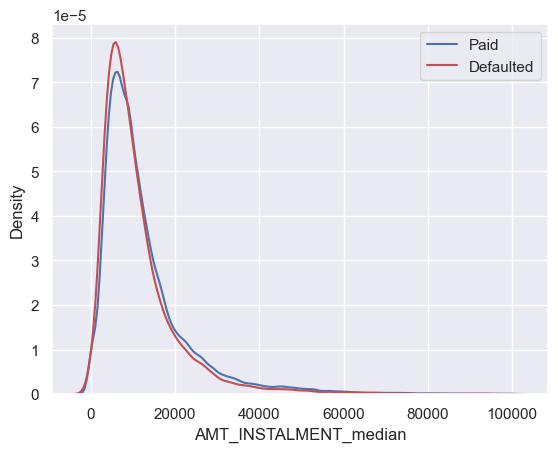

In [32]:
plot_kde_vs_target('AMT_INSTALMENT_median', good_frame)
median_vs_target('AMT_INSTALMENT_median', good_frame)

(-0.001, 3845.7]          9.985161
(3845.7, 5434.47]         9.453152
(5434.47, 6876.495]       9.074326
(6876.495, 8586.83]       8.514717
(8586.83, 10359.035]      7.994806
(10359.035, 12731.535]    7.889693
(12731.535, 16274.79]     7.425941
(16274.79, 23413.17]      7.200099
(23413.17, 99870.615]     6.195320
Name: AMT_INSTALMENT_median_binned, dtype: float64


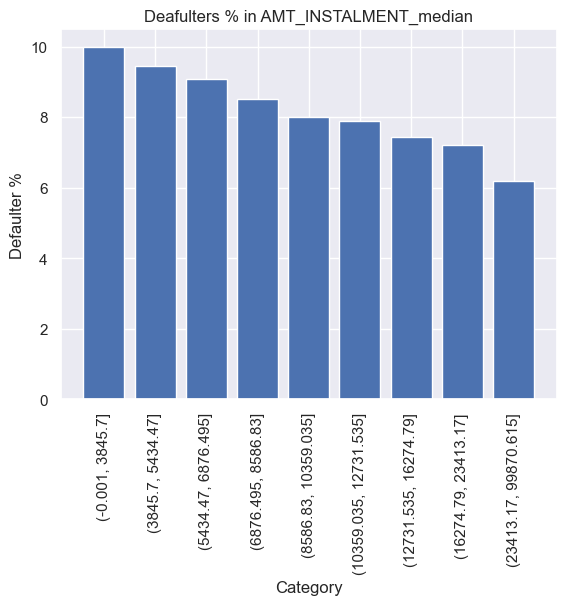

In [33]:
plot_hist_default_pct('AMT_INSTALMENT_median', good_frame, 9)

### AMT_PAYMENT_DIFFERENCE_PCT_max

In [34]:
numerical_frame['AMT_PAYMENT_DIFFERENCE_PCT_max'].isnull().sum()

8

In [35]:
numerical_frame['AMT_PAYMENT_DIFFERENCE_PCT_max'].describe()

count    2.916350e+05
mean             -inf
std               NaN
min              -inf
25%      0.000000e+00
50%      0.000000e+00
75%      9.855549e+01
max      1.000000e+02
Name: AMT_PAYMENT_DIFFERENCE_PCT_max, dtype: float64

In [37]:
numerical_frame.replace(to_replace={'AMT_PAYMENT_DIFFERENCE_PCT_max': {-np.inf: np.nan}}, inplace=True)

array([<Axes: >, <Axes: >], dtype=object)

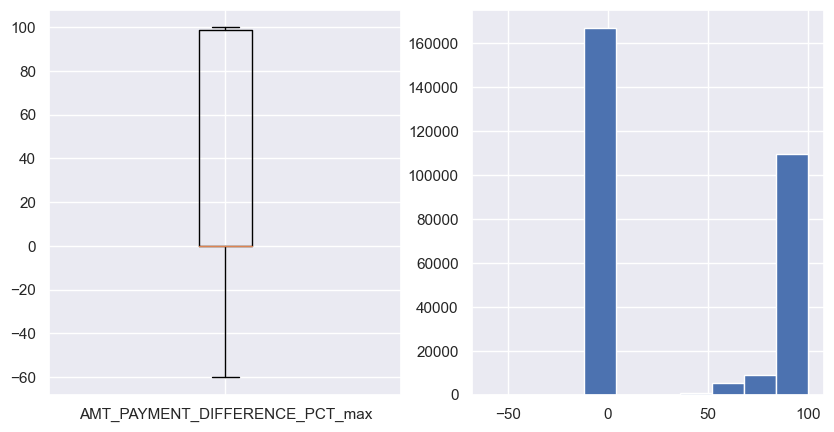

In [38]:
plot_hist_box(numerical_frame, 'AMT_PAYMENT_DIFFERENCE_PCT_max')

Median of AMT_PAYMENT_DIFFERENCE_PCT_max with target=0 : 0.000000
Median of AMT_PAYMENT_DIFFERENCE_PCT_max with target=1 : 52.626791


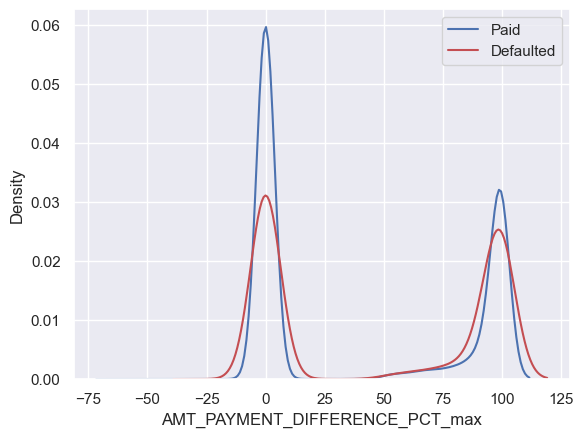

In [39]:
plot_kde_vs_target('AMT_PAYMENT_DIFFERENCE_PCT_max', numerical_frame)
median_vs_target('AMT_PAYMENT_DIFFERENCE_PCT_max', numerical_frame)

(-60.050999999999995, 0.0]     7.103300
(0.0, 93.451]                  9.382495
(93.451, 99.061]              10.023454
(99.061, 99.904]               9.631824
(99.904, 100.0]                9.440193
Name: AMT_PAYMENT_DIFFERENCE_PCT_max_binned, dtype: float64


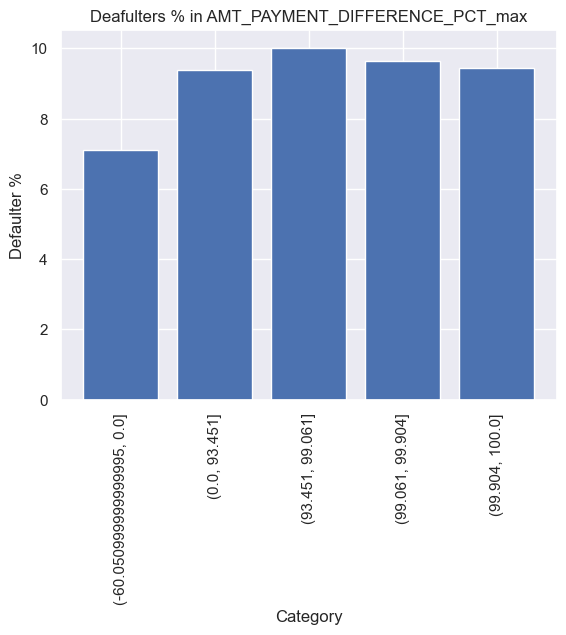

In [40]:
plot_hist_default_pct('AMT_PAYMENT_DIFFERENCE_PCT_max', numerical_frame, 9)

### AMT_PAYMENT_DIFFERENCE_max

In [44]:
numerical_frame['AMT_PAYMENT_DIFFERENCE_max'].isnull().sum()

8

In [45]:
numerical_frame['AMT_PAYMENT_DIFFERENCE_max'].describe()

count    2.916350e+05
mean     6.724317e+03
std      1.517534e+04
min     -3.899106e+04
25%      0.000000e+00
50%      0.000000e+00
75%      9.047632e+03
max      2.424726e+06
Name: AMT_PAYMENT_DIFFERENCE_max, dtype: float64

array([<Axes: >, <Axes: >], dtype=object)

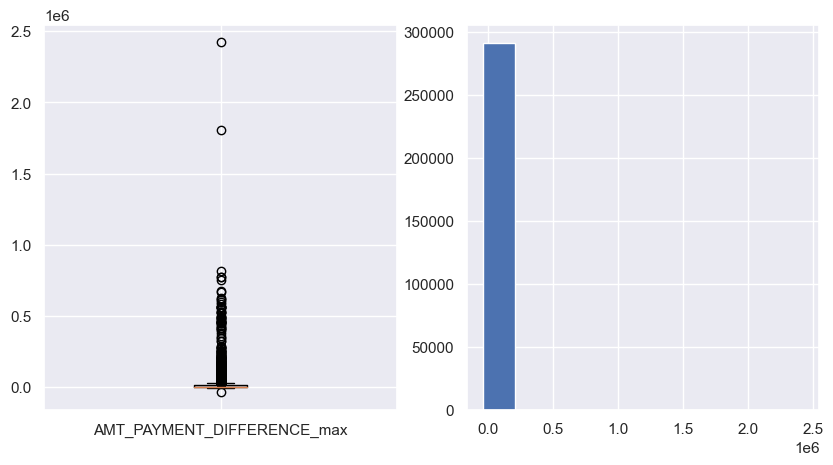

In [46]:
plot_hist_box(numerical_frame, 'AMT_PAYMENT_DIFFERENCE_max')

Number of outliers : 120


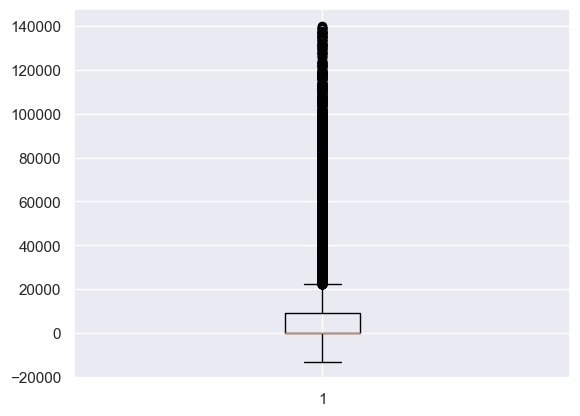

In [57]:
'''
this cell adjusts the outlier range, marks outlier records (nans remain unchanged), and also scales the data to year scale.
'''

plt.boxplot(numerical_frame.loc[(numerical_frame['AMT_PAYMENT_DIFFERENCE_max']<0.14e6) & 
                                (numerical_frame['AMT_PAYMENT_DIFFERENCE_max']>-25000), 'AMT_PAYMENT_DIFFERENCE_max']);
numerical_frame['AMT_PAYMENT_DIFFERENCE_max_outlier']=0
numerical_frame.loc[(numerical_frame['AMT_PAYMENT_DIFFERENCE_max']>=0.14e6) | 
                    (numerical_frame['AMT_PAYMENT_DIFFERENCE_max']<=-25000), 'AMT_PAYMENT_DIFFERENCE_max_outlier']=1
good_frame=numerical_frame.loc[numerical_frame['AMT_PAYMENT_DIFFERENCE_max_outlier']==0, :]
print('Number of outliers : %d'%((numerical_frame['AMT_PAYMENT_DIFFERENCE_max_outlier']==1).sum()))

array([<Axes: >, <Axes: >], dtype=object)

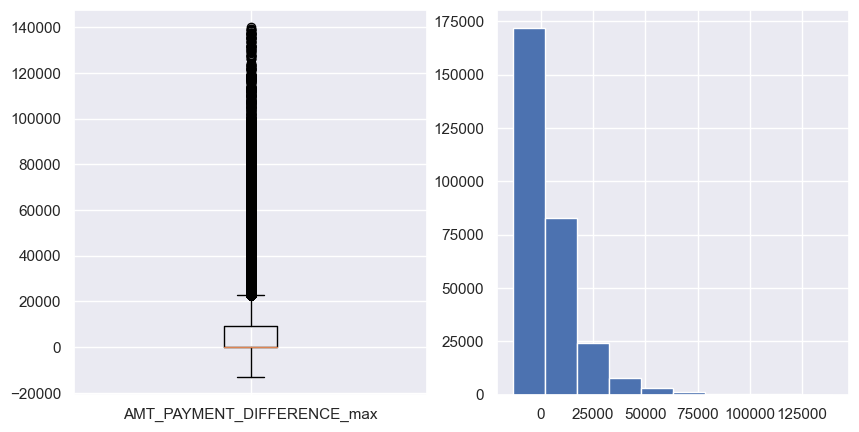

In [58]:
plot_hist_box(good_frame, 'AMT_PAYMENT_DIFFERENCE_max')

Median of AMT_PAYMENT_DIFFERENCE_max with target=0 : 0.000000
Median of AMT_PAYMENT_DIFFERENCE_max with target=1 : 237.285000


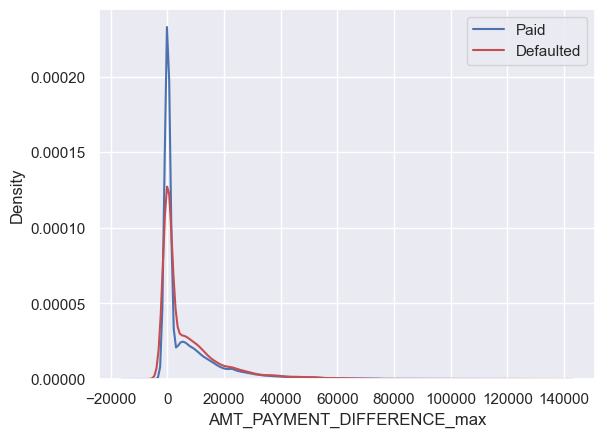

In [59]:
plot_kde_vs_target('AMT_PAYMENT_DIFFERENCE_max', good_frame)
median_vs_target('AMT_PAYMENT_DIFFERENCE_max', good_frame)

(-13193.326000000001, 0.0]    7.103215
(0.0, 5473.155]               9.614073
(5473.155, 10487.49]          9.802106
(10487.49, 19303.575]         9.709787
(19303.575, 139991.49]        9.382236
Name: AMT_PAYMENT_DIFFERENCE_max_binned, dtype: float64


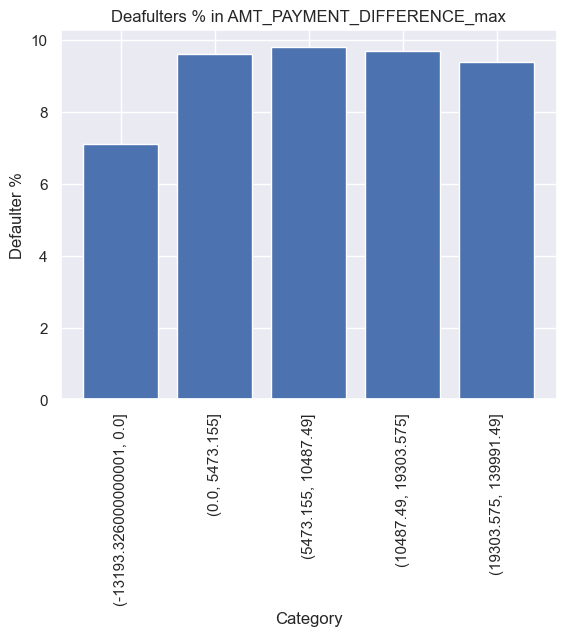

In [62]:
plot_hist_default_pct('AMT_PAYMENT_DIFFERENCE_max', good_frame, 9)

### AMT_PAYMENT_DIFFERENCE_sum

In [63]:
numerical_frame['AMT_PAYMENT_DIFFERENCE_sum'].isnull().sum()

0

In [64]:
numerical_frame['AMT_PAYMENT_DIFFERENCE_sum'].describe()

count    2.916430e+05
mean    -6.310439e+03
std      1.749791e+05
min     -4.417384e+06
25%      0.000000e+00
50%      0.000000e+00
75%      1.589697e+04
max      3.037736e+06
Name: AMT_PAYMENT_DIFFERENCE_sum, dtype: float64

array([<Axes: >, <Axes: >], dtype=object)

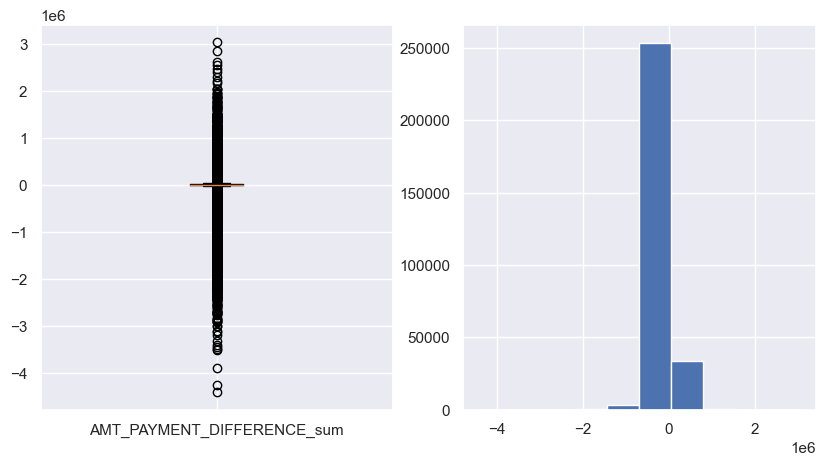

In [65]:
plot_hist_box(numerical_frame, 'AMT_PAYMENT_DIFFERENCE_sum')

Number of outliers : 91


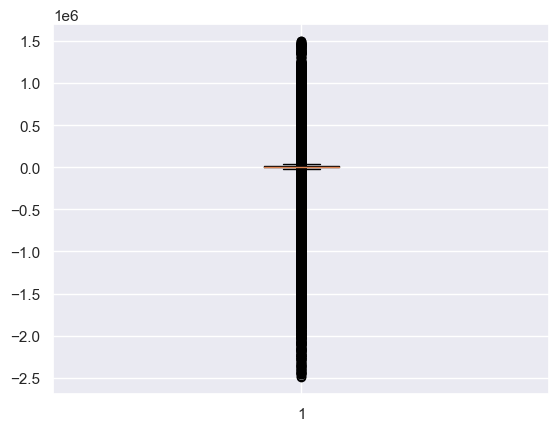

In [71]:
'''
this cell adjusts the outlier range, marks outlier records (nans remain unchanged), and also scales the data to year scale.
'''

plt.boxplot(numerical_frame.loc[(numerical_frame['AMT_PAYMENT_DIFFERENCE_sum']<1.5e6) & 
                                (numerical_frame['AMT_PAYMENT_DIFFERENCE_sum']>-2.5e6), 'AMT_PAYMENT_DIFFERENCE_sum']);
numerical_frame['AMT_PAYMENT_DIFFERENCE_sum_outlier']=0
numerical_frame.loc[(numerical_frame['AMT_PAYMENT_DIFFERENCE_sum']>=1.5e6) | 
                    (numerical_frame['AMT_PAYMENT_DIFFERENCE_sum']<=-2.5e6), 'AMT_PAYMENT_DIFFERENCE_sum_outlier']=1
good_frame=numerical_frame.loc[numerical_frame['AMT_PAYMENT_DIFFERENCE_sum_outlier']==0, :]
print('Number of outliers : %d'%((numerical_frame['AMT_PAYMENT_DIFFERENCE_sum_outlier']==1).sum()))

array([<Axes: >, <Axes: >], dtype=object)

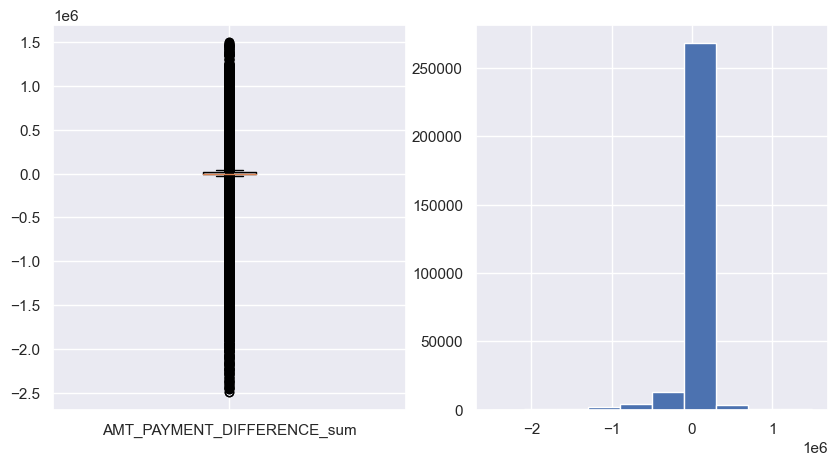

In [72]:
plot_hist_box(good_frame, 'AMT_PAYMENT_DIFFERENCE_sum')

Median of AMT_PAYMENT_DIFFERENCE_sum with target=0 : 0.000000
Median of AMT_PAYMENT_DIFFERENCE_sum with target=1 : 0.000000


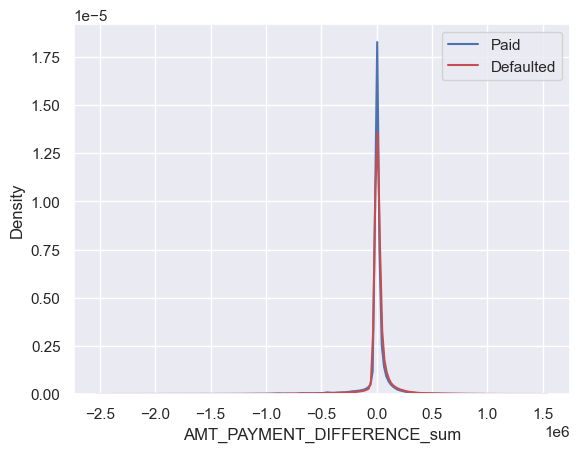

In [73]:
plot_kde_vs_target('AMT_PAYMENT_DIFFERENCE_sum', good_frame)
median_vs_target('AMT_PAYMENT_DIFFERENCE_sum', good_frame)

(-2490804.901, -6633.18]     6.149097
(-6633.18, 0.0]              7.355709
(0.0, 6129.72]               9.550480
(6129.72, 20517.04]          9.807372
(20517.04, 59559.305]        9.989196
(59559.305, 1497472.155]    10.044760
Name: AMT_PAYMENT_DIFFERENCE_sum_binned, dtype: float64


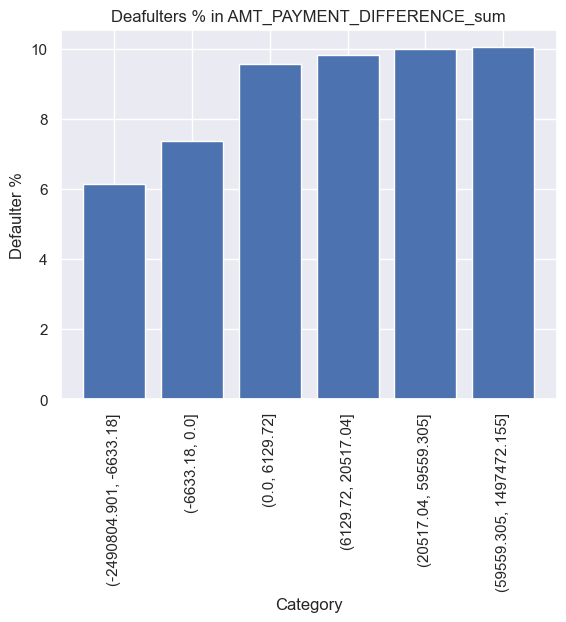

In [74]:
plot_hist_default_pct('AMT_PAYMENT_DIFFERENCE_sum', good_frame, 9)

### DAYS_INSTALMENT_median

In [75]:
numerical_frame['DAYS_INSTALMENT_median'].isnull().sum()

0

In [76]:
numerical_frame['DAYS_INSTALMENT_median'].describe()

count    291643.000000
mean       -881.164787
std         662.849023
min       -2922.000000
25%       -1297.000000
50%        -667.000000
75%        -353.000000
max          -3.000000
Name: DAYS_INSTALMENT_median, dtype: float64

array([<Axes: >, <Axes: >], dtype=object)

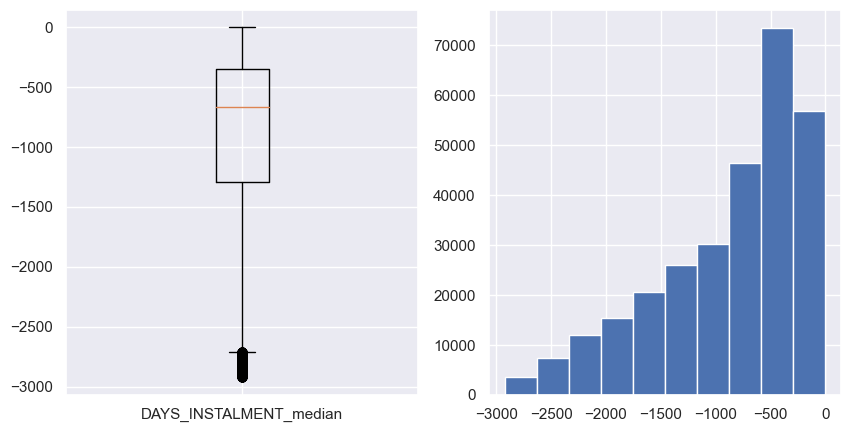

In [77]:
plot_hist_box(numerical_frame, 'DAYS_INSTALMENT_median')

Median of DAYS_INSTALMENT_median with target=0 : -677.000000
Median of DAYS_INSTALMENT_median with target=1 : -561.000000


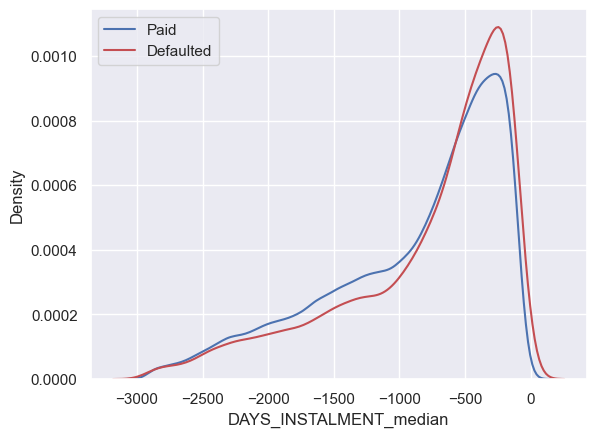

In [78]:
plot_kde_vs_target('DAYS_INSTALMENT_median', numerical_frame)
median_vs_target('DAYS_INSTALMENT_median', numerical_frame)

(-2922.001, -1858.0]     7.162466
(-1858.0, -1390.0]       6.614678
(-1390.0, -1040.0]       6.633566
(-1040.0, -767.0]        7.521578
(-767.0, -583.0]         7.674971
(-583.0, -444.0]         8.522990
(-444.0, -323.0]         8.786315
(-323.0, -208.0]         9.366579
(-208.0, -3.0]          11.413885
Name: DAYS_INSTALMENT_median_binned, dtype: float64


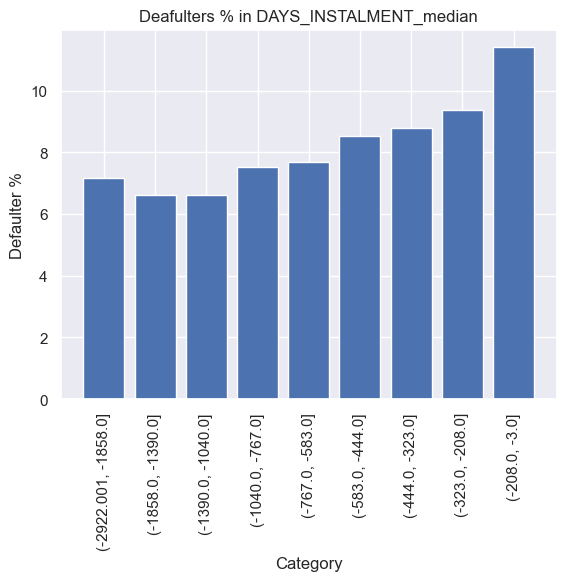

In [79]:
plot_hist_default_pct('DAYS_INSTALMENT_median', numerical_frame, 9)

### DAYS_INSTALMENT_min (mi, less outliers and more varaibility in graph)

In [80]:
numerical_frame['DAYS_INSTALMENT_min'].isnull().sum()

0

In [81]:
numerical_frame['DAYS_INSTALMENT_min'].describe()

count    291643.000000
mean      -1584.949140
std         913.707997
min       -2922.000000
25%       -2471.000000
50%       -1539.000000
75%        -713.000000
max          -3.000000
Name: DAYS_INSTALMENT_min, dtype: float64

array([<Axes: >, <Axes: >], dtype=object)

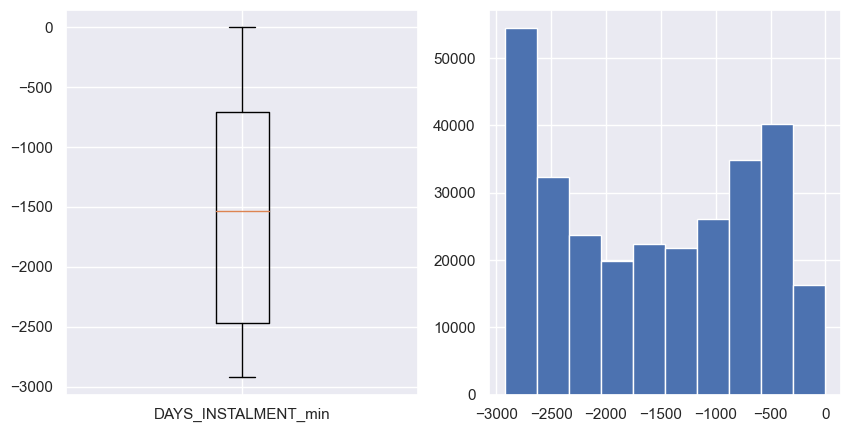

In [82]:
plot_hist_box(numerical_frame, 'DAYS_INSTALMENT_min')

Median of DAYS_INSTALMENT_min with target=0 : -1567.000000
Median of DAYS_INSTALMENT_min with target=1 : -1212.000000


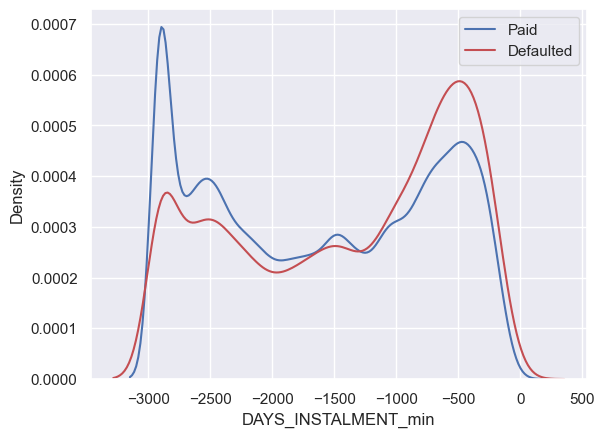

In [83]:
plot_kde_vs_target('DAYS_INSTALMENT_min', numerical_frame)
median_vs_target('DAYS_INSTALMENT_min', numerical_frame)

(-2922.001, -2855.0]     5.803585
(-2855.0, -2540.0]       6.409112
(-2540.0, -2217.0]       7.180802
(-2217.0, -1763.0]       7.199506
(-1763.0, -1344.0]       7.941603
(-1344.0, -943.0]        8.438714
(-943.0, -652.0]         9.715010
(-652.0, -416.0]        10.493599
(-416.0, -3.0]          10.506270
Name: DAYS_INSTALMENT_min_binned, dtype: float64


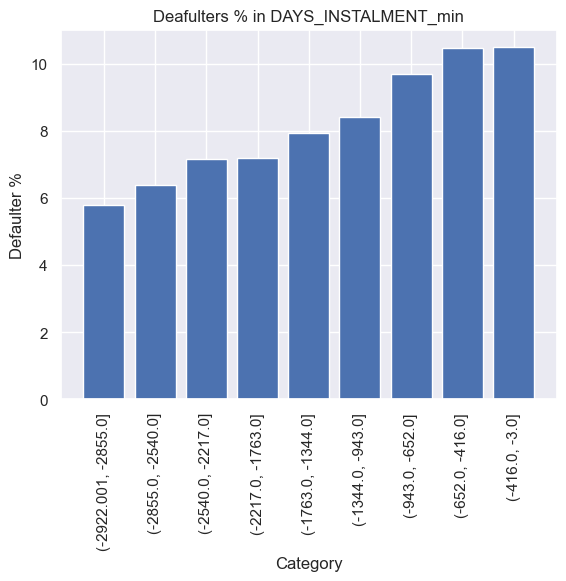

In [84]:
plot_hist_default_pct('DAYS_INSTALMENT_min', numerical_frame, 9)

### DAYS_PAYMENT_DIFFERENCE_max

In [85]:
numerical_frame['DAYS_PAYMENT_DIFFERENCE_max'].isnull().sum()

8

In [86]:
numerical_frame['DAYS_PAYMENT_DIFFERENCE_max'].describe()

count    291635.000000
mean         16.231262
std         111.096364
min        -156.000000
25%          -2.000000
50%           1.000000
75%           9.000000
max        2884.000000
Name: DAYS_PAYMENT_DIFFERENCE_max, dtype: float64

array([<Axes: >, <Axes: >], dtype=object)

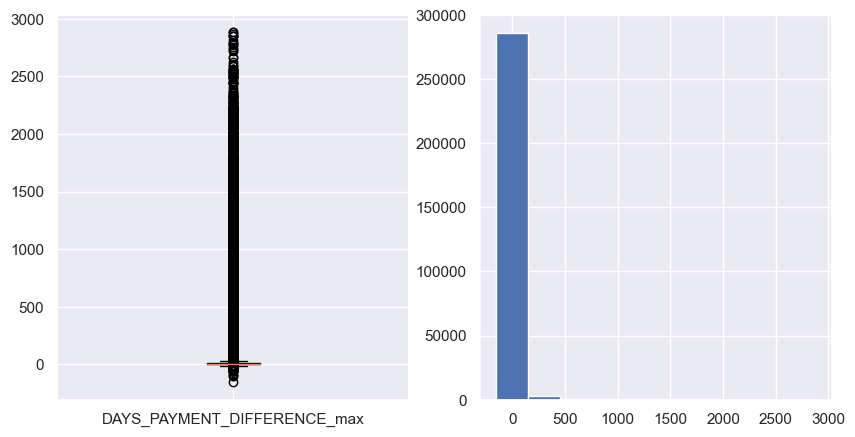

In [87]:
plot_hist_box(numerical_frame, 'DAYS_PAYMENT_DIFFERENCE_max')

Median of DAYS_PAYMENT_DIFFERENCE_max with target=0 : 1.000000
Median of DAYS_PAYMENT_DIFFERENCE_max with target=1 : 3.000000


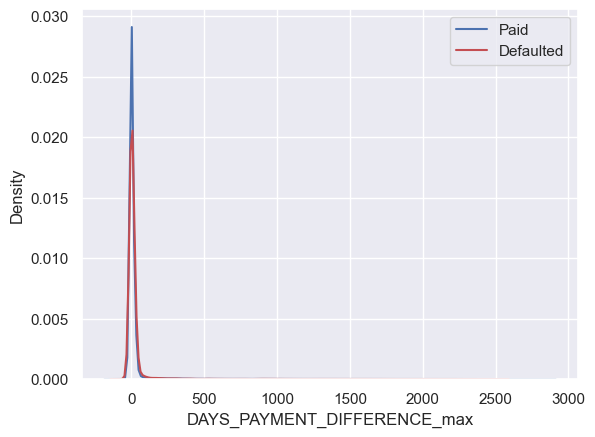

In [91]:
plot_kde_vs_target('DAYS_PAYMENT_DIFFERENCE_max', numerical_frame)
median_vs_target('DAYS_PAYMENT_DIFFERENCE_max', numerical_frame)

(-156.001, -8.0]     6.833421
(-8.0, -3.0]         6.807822
(-3.0, 0.0]          6.780430
(0.0, 2.0]           8.336255
(2.0, 5.0]           8.898776
(5.0, 11.0]          9.827116
(11.0, 24.0]         9.718201
(24.0, 2884.0]      10.132674
Name: DAYS_PAYMENT_DIFFERENCE_max_binned, dtype: float64


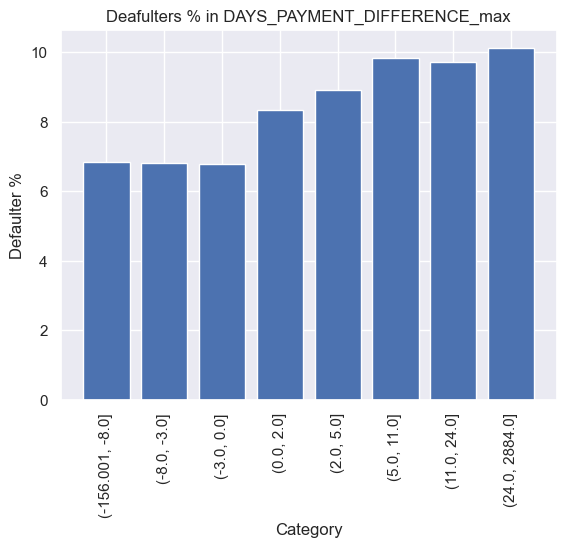

In [93]:
plot_hist_default_pct('DAYS_PAYMENT_DIFFERENCE_max', numerical_frame, 9)

### DAYS_PAYMENT_DIFFERENCE_median (mi, most variability in bar graph)

In [101]:
numerical_frame['DAYS_PAYMENT_DIFFERENCE_median'].isnull().sum()

8

In [102]:
numerical_frame['DAYS_PAYMENT_DIFFERENCE_median'].describe()

count    291635.000000
mean         -9.663897
std          11.137918
min        -310.000000
25%         -13.000000
50%          -8.000000
75%          -3.000000
max        2135.500000
Name: DAYS_PAYMENT_DIFFERENCE_median, dtype: float64

array([<Axes: >, <Axes: >], dtype=object)

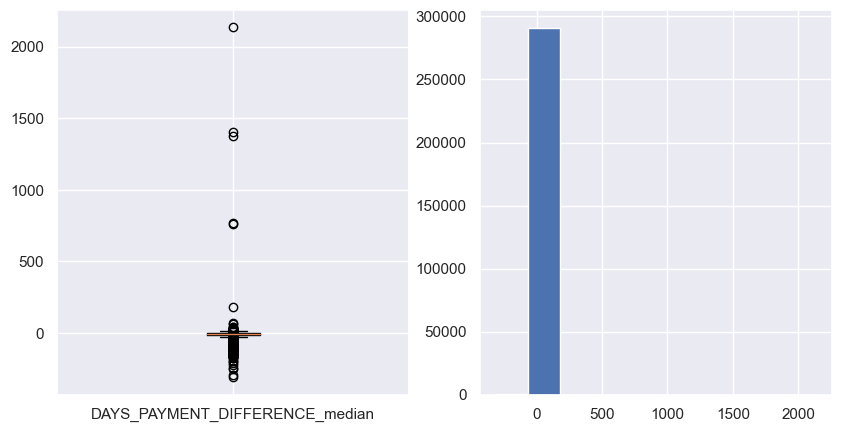

In [103]:
plot_hist_box(numerical_frame, 'DAYS_PAYMENT_DIFFERENCE_median')

Median of DAYS_PAYMENT_DIFFERENCE_median with target=0 : -8.000000
Median of DAYS_PAYMENT_DIFFERENCE_median with target=1 : -7.000000


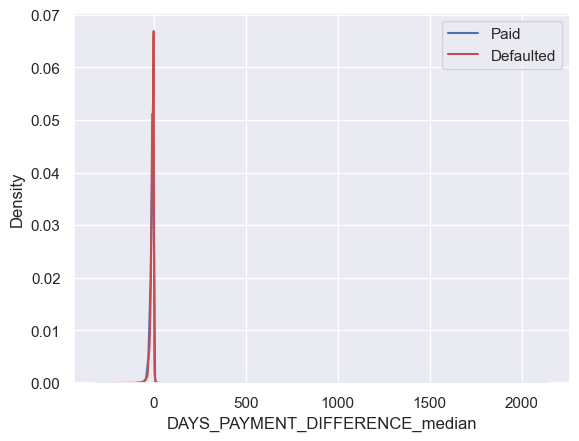

In [104]:
plot_kde_vs_target('DAYS_PAYMENT_DIFFERENCE_median', numerical_frame)
median_vs_target('DAYS_PAYMENT_DIFFERENCE_median', numerical_frame)

(-310.001, -19.0]     7.470341
(-19.0, -14.0]        6.788148
(-14.0, -11.0]        7.127940
(-11.0, -9.0]         7.365933
(-9.0, -7.0]          7.988364
(-7.0, -5.0]          7.934859
(-5.0, -3.0]          8.982610
(-3.0, 0.0]           9.942868
(0.0, 2135.5]        15.846209
Name: DAYS_PAYMENT_DIFFERENCE_median_binned, dtype: float64


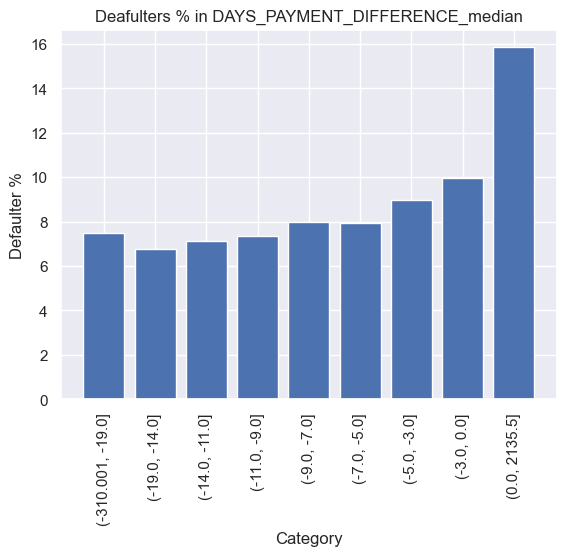

In [105]:
plot_hist_default_pct('DAYS_PAYMENT_DIFFERENCE_median', numerical_frame, 9)

### DAYS_PAYMENT_DIFFERENCE_sum

In [106]:
numerical_frame['DAYS_PAYMENT_DIFFERENCE_sum'].isnull().sum()

0

In [107]:
numerical_frame['DAYS_PAYMENT_DIFFERENCE_sum'].describe()

count    291643.000000
mean       -348.019846
std         512.608006
min      -10529.000000
25%        -468.000000
50%        -240.000000
75%        -116.000000
max       82905.000000
Name: DAYS_PAYMENT_DIFFERENCE_sum, dtype: float64

array([<Axes: >, <Axes: >], dtype=object)

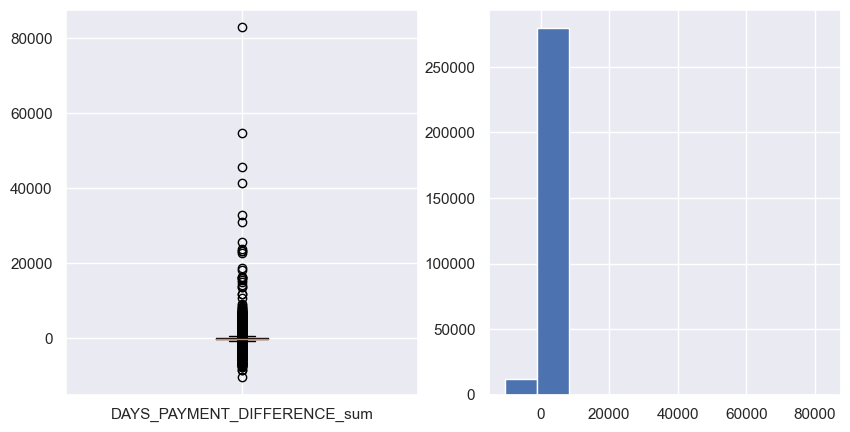

In [108]:
plot_hist_box(numerical_frame, 'DAYS_PAYMENT_DIFFERENCE_sum')

Median of DAYS_PAYMENT_DIFFERENCE_sum with target=0 : -244.000000
Median of DAYS_PAYMENT_DIFFERENCE_sum with target=1 : -199.000000


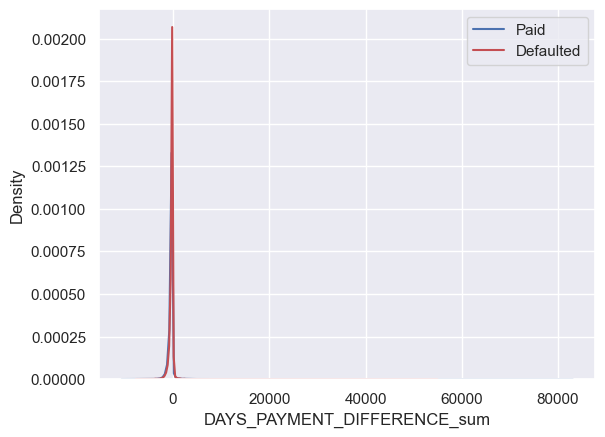

In [109]:
plot_kde_vs_target('DAYS_PAYMENT_DIFFERENCE_sum', numerical_frame)
median_vs_target('DAYS_PAYMENT_DIFFERENCE_sum', numerical_frame)

(-10529.001, -770.0]     6.177868
(-770.0, -509.0]         6.501338
(-509.0, -370.0]         7.274631
(-370.0, -277.0]         7.581961
(-277.0, -208.0]         8.072836
(-208.0, -152.0]         8.653788
(-152.0, -105.0]         9.152848
(-105.0, -59.0]          9.691046
(-59.0, 82905.0]        10.597075
Name: DAYS_PAYMENT_DIFFERENCE_sum_binned, dtype: float64


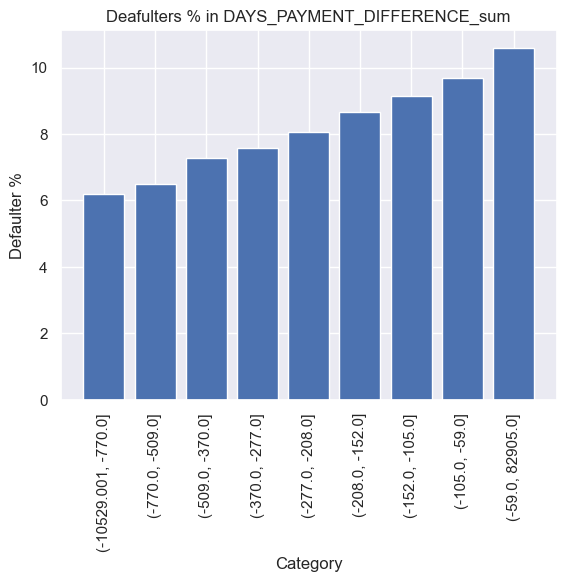

In [110]:
plot_hist_default_pct('DAYS_PAYMENT_DIFFERENCE_sum', numerical_frame, 9)

### LATE_PAYMENT_PCT_max

In [111]:
numerical_frame['LATE_PAYMENT_PCT_max'].isnull().sum()

0

In [112]:
numerical_frame['LATE_PAYMENT_PCT_max'].describe()

count    291643.000000
mean         13.930248
std          18.877059
min           0.000000
25%           0.000000
50%           4.651163
75%          24.137931
max         100.000000
Name: LATE_PAYMENT_PCT_max, dtype: float64

array([<Axes: >, <Axes: >], dtype=object)

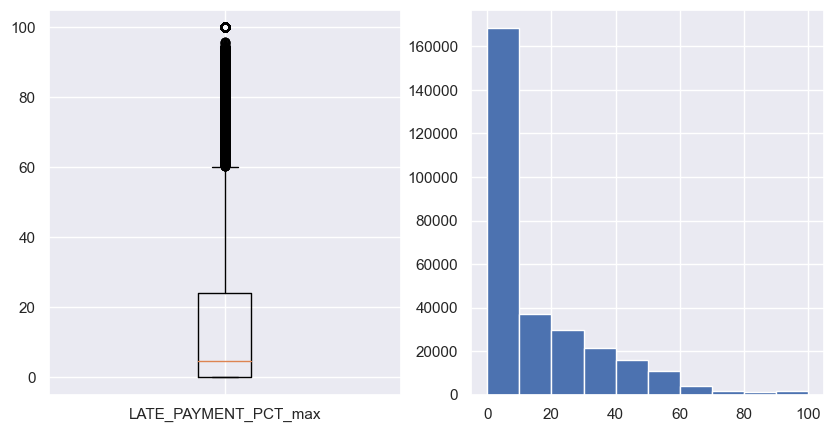

In [113]:
plot_hist_box(numerical_frame, 'LATE_PAYMENT_PCT_max')

Median of LATE_PAYMENT_PCT_max with target=0 : 4.081633
Median of LATE_PAYMENT_PCT_max with target=1 : 10.000000


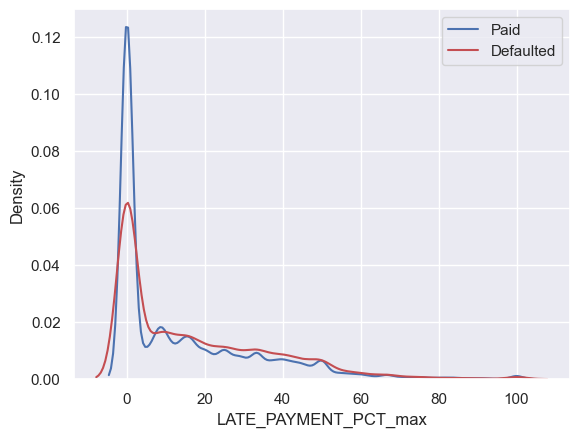

In [114]:
plot_kde_vs_target('LATE_PAYMENT_PCT_max', numerical_frame)
median_vs_target('LATE_PAYMENT_PCT_max', numerical_frame)

(-0.001, 8.333]      6.959649
(8.333, 16.667]      9.016974
(16.667, 26.316]     9.668605
(26.316, 40.0]      10.220667
(40.0, 100.0]       10.194587
Name: LATE_PAYMENT_PCT_max_binned, dtype: float64


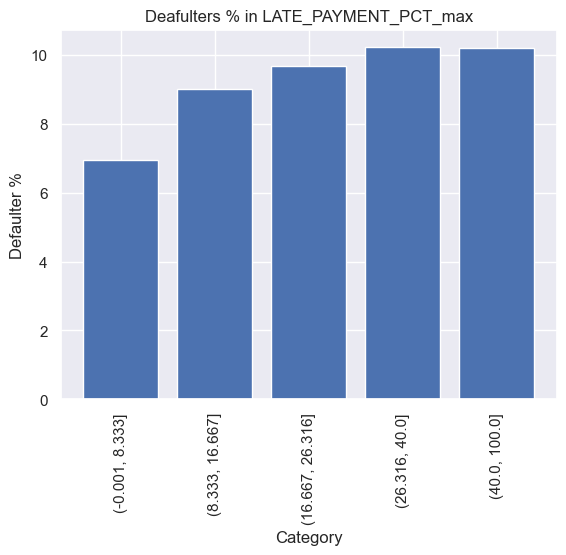

In [115]:
plot_hist_default_pct('LATE_PAYMENT_PCT_max', numerical_frame, 9)

### LATE_PAYMENT_sum

In [116]:
numerical_frame['LATE_PAYMENT_sum'].isnull().sum()

0

In [117]:
numerical_frame['LATE_PAYMENT_sum'].describe()

count    291643.000000
mean          3.407004
std           6.397206
min           0.000000
25%           0.000000
50%           1.000000
75%           4.000000
max         159.000000
Name: LATE_PAYMENT_sum, dtype: float64

array([<Axes: >, <Axes: >], dtype=object)

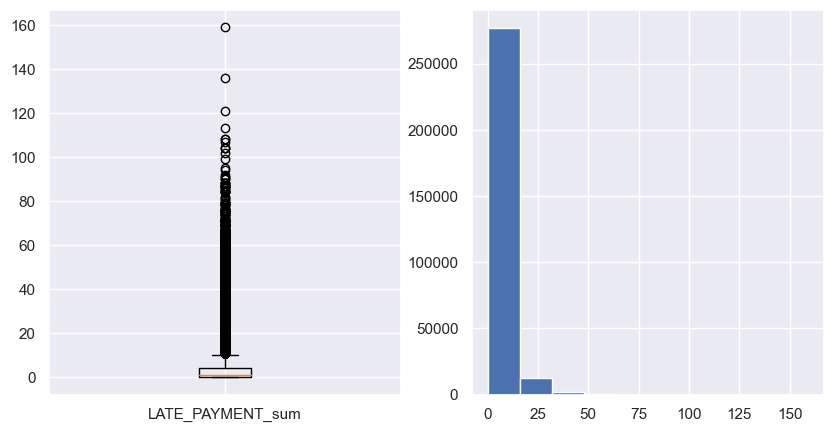

In [118]:
plot_hist_box(numerical_frame, 'LATE_PAYMENT_sum')

Median of LATE_PAYMENT_sum with target=0 : 1.000000
Median of LATE_PAYMENT_sum with target=1 : 1.000000


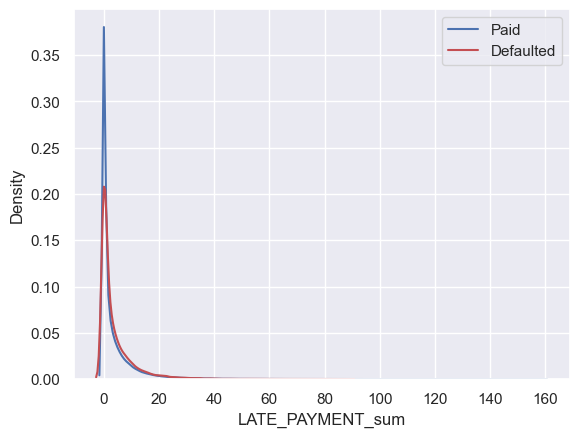

In [119]:
plot_kde_vs_target('LATE_PAYMENT_sum', numerical_frame)
median_vs_target('LATE_PAYMENT_sum', numerical_frame)

(-0.001, 1.0]    7.177822
(1.0, 2.0]       9.264469
(2.0, 5.0]       9.656517
(5.0, 9.0]       9.837954
(9.0, 159.0]     9.827896
Name: LATE_PAYMENT_sum_binned, dtype: float64


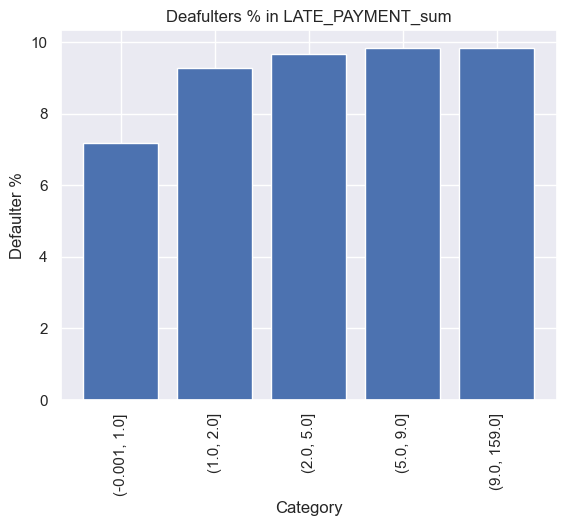

In [120]:
plot_hist_default_pct('LATE_PAYMENT_sum', numerical_frame, 9)

### MISSED_PAYMENT_sum

In [121]:
numerical_frame['MISSED_PAYMENT_sum'].isnull().sum()

0

In [122]:
numerical_frame['MISSED_PAYMENT_sum'].describe()

count    291643.000000
mean          1.380198
std           3.199361
min           0.000000
25%           0.000000
50%           0.000000
75%           1.000000
max          61.000000
Name: MISSED_PAYMENT_sum, dtype: float64

array([<Axes: >, <Axes: >], dtype=object)

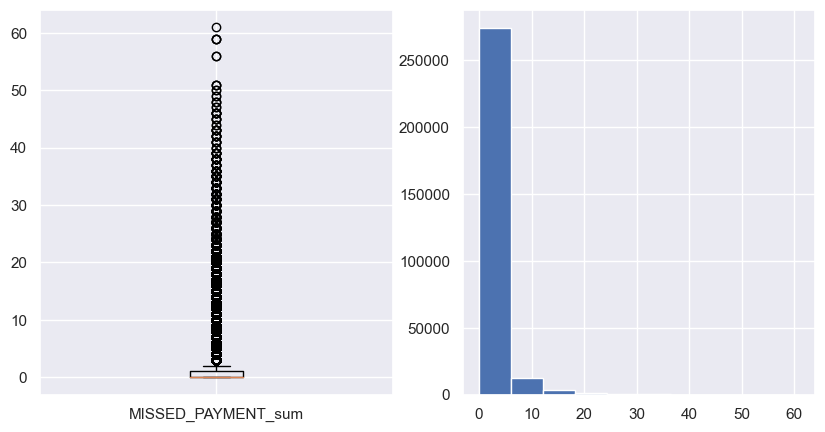

In [123]:
plot_hist_box(numerical_frame, 'MISSED_PAYMENT_sum')

Median of MISSED_PAYMENT_sum with target=0 : 0.000000
Median of MISSED_PAYMENT_sum with target=1 : 0.000000


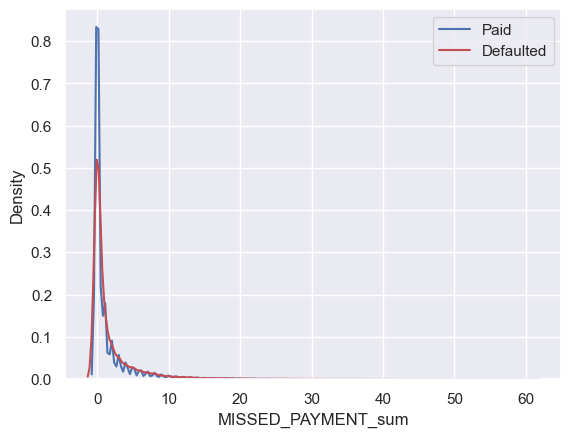

In [124]:
plot_kde_vs_target('MISSED_PAYMENT_sum', numerical_frame)
median_vs_target('MISSED_PAYMENT_sum', numerical_frame)

(-0.001, 1.0]     7.661394
(1.0, 2.0]       10.147581
(2.0, 4.0]       10.126649
(4.0, 61.0]       9.806461
Name: MISSED_PAYMENT_sum_binned, dtype: float64


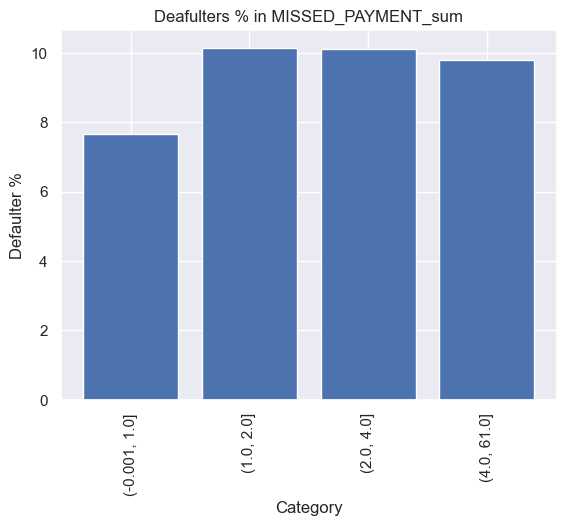

In [125]:
plot_hist_default_pct('MISSED_PAYMENT_sum', numerical_frame, 9)

### RECORDS_median

In [126]:
numerical_frame['RECORDS_median'].isnull().sum()

0

In [127]:
numerical_frame['RECORDS_median'].describe()

count    291643.000000
mean         11.469236
std          10.029755
min           1.000000
25%           6.500000
50%          10.000000
75%          12.500000
max         220.000000
Name: RECORDS_median, dtype: float64

array([<Axes: >, <Axes: >], dtype=object)

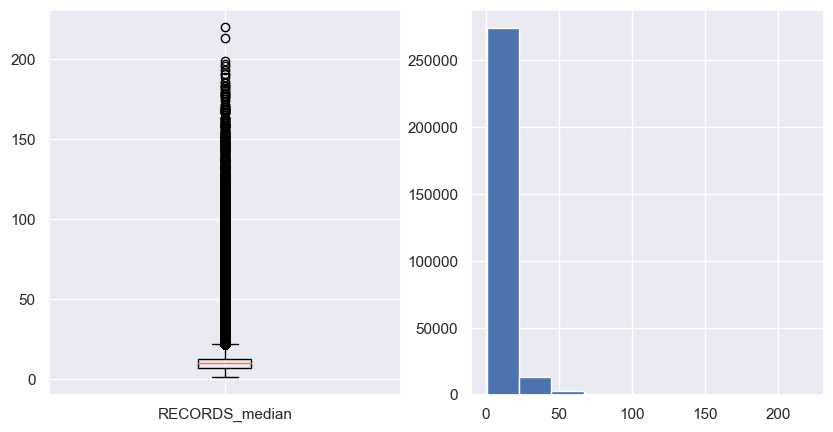

In [128]:
plot_hist_box(numerical_frame, 'RECORDS_median')

Median of RECORDS_median with target=0 : 10.000000
Median of RECORDS_median with target=1 : 10.000000


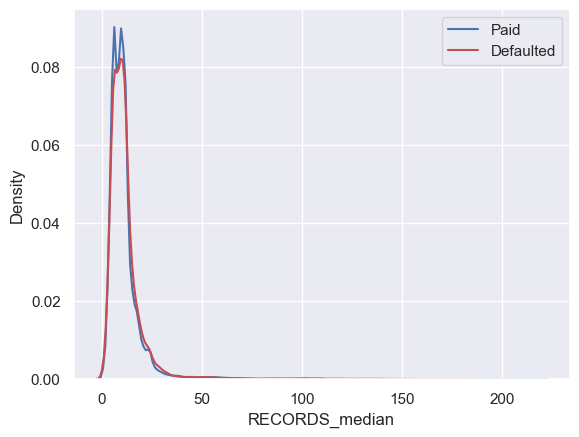

In [129]:
plot_kde_vs_target('RECORDS_median', good_frame)
median_vs_target('RECORDS_median', good_frame)

(0.999, 5.0]     7.700558
(5.0, 6.0]       7.365532
(6.0, 8.0]       8.083784
(8.0, 9.0]       7.838101
(9.0, 10.0]      7.677241
(10.0, 12.0]     7.943641
(12.0, 13.0]     9.692986
(13.0, 18.0]     9.445499
(18.0, 220.0]    9.081517
Name: RECORDS_median_binned, dtype: float64


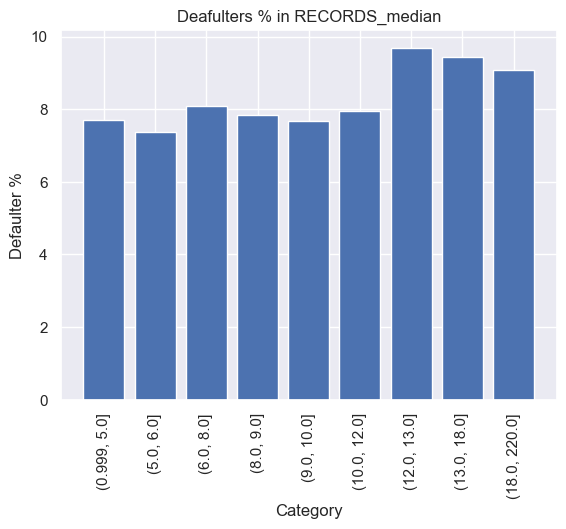

In [130]:
plot_hist_default_pct('RECORDS_median', numerical_frame, 9)

### RECORDS_min

In [131]:
numerical_frame['RECORDS_min'].isnull().sum()

0

In [132]:
numerical_frame['RECORDS_min'].describe()

count    291643.000000
mean          7.518518
std           8.406885
min           1.000000
25%           4.000000
50%           6.000000
75%          10.000000
max         220.000000
Name: RECORDS_min, dtype: float64

array([<Axes: >, <Axes: >], dtype=object)

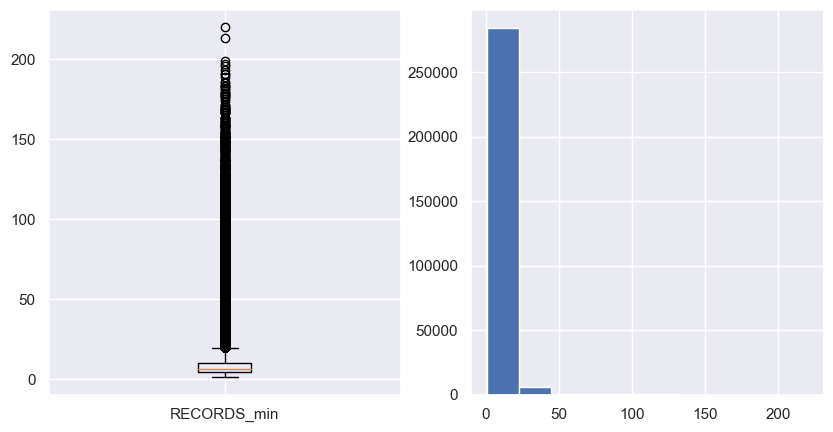

In [133]:
plot_hist_box(numerical_frame, 'RECORDS_min')

Median of RECORDS_min with target=0 : 6.000000
Median of RECORDS_min with target=1 : 6.000000


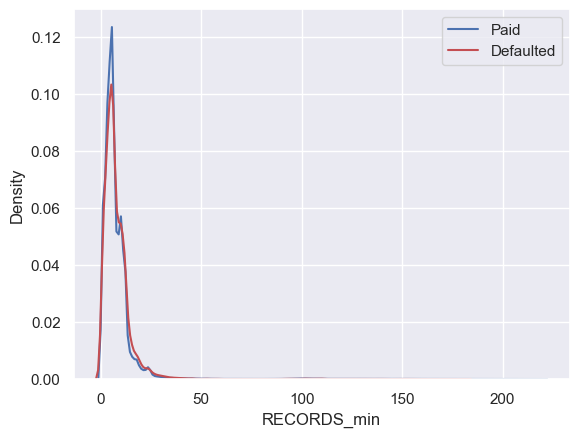

In [134]:
plot_kde_vs_target('RECORDS_min', numerical_frame)
median_vs_target('RECORDS_min', numerical_frame)

(0.999, 2.0]      7.925755
(2.0, 4.0]        7.291596
(4.0, 6.0]        7.497177
(6.0, 8.0]        8.959036
(8.0, 10.0]       8.198480
(10.0, 12.0]      8.817044
(12.0, 220.0]    10.718390
Name: RECORDS_min_binned, dtype: float64


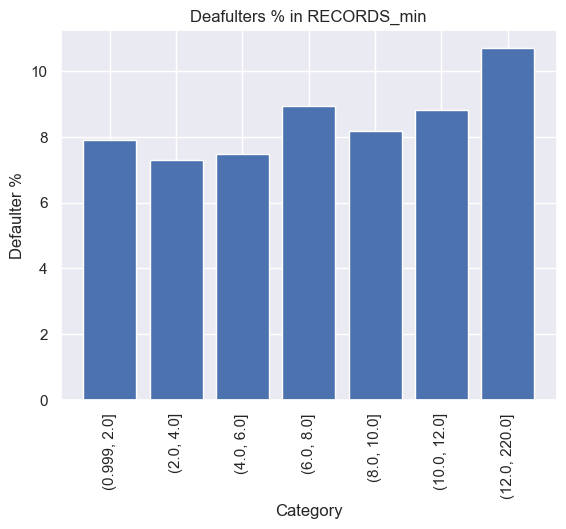

In [135]:
plot_hist_default_pct('RECORDS_min', numerical_frame, 9)

### Dropping Unimportant Variables

In [136]:
numerical_frame.columns.sort_values()

Index(['AMT_INSTALMENT_median', 'AMT_INSTALMENT_median_outlier',
       'AMT_PAYMENT_DIFFERENCE_PCT_max', 'AMT_PAYMENT_DIFFERENCE_max',
       'AMT_PAYMENT_DIFFERENCE_max_outlier', 'AMT_PAYMENT_DIFFERENCE_sum',
       'AMT_PAYMENT_DIFFERENCE_sum_outlier', 'DAYS_INSTALMENT_median',
       'DAYS_INSTALMENT_min', 'DAYS_PAYMENT_DIFFERENCE_max',
       'DAYS_PAYMENT_DIFFERENCE_median', 'DAYS_PAYMENT_DIFFERENCE_sum',
       'LATE_PAYMENT_PCT_max', 'LATE_PAYMENT_sum', 'MISSED_PAYMENT_sum',
       'RECORDS_median', 'RECORDS_min', 'SK_ID_CURR', 'TARGET'],
      dtype='object')

In [137]:
numerical_frame.drop(labels=['RECORDS_median', 'RECORDS_min', 
                             'AMT_PAYMENT_DIFFERENCE_PCT_max', 'AMT_PAYMENT_DIFFERENCE_max',
                             'AMT_PAYMENT_DIFFERENCE_max_outlier', 'DAYS_INSTALMENT_median',
                             'DAYS_PAYMENT_DIFFERENCE_max', 'LATE_PAYMENT_sum', 'MISSED_PAYMENT_sum'], 
                             axis=1, inplace=True)
numerical_frame.columns.sort_values()

Index(['AMT_INSTALMENT_median', 'AMT_INSTALMENT_median_outlier',
       'AMT_PAYMENT_DIFFERENCE_sum', 'AMT_PAYMENT_DIFFERENCE_sum_outlier',
       'DAYS_INSTALMENT_min', 'DAYS_PAYMENT_DIFFERENCE_median',
       'DAYS_PAYMENT_DIFFERENCE_sum', 'LATE_PAYMENT_PCT_max', 'SK_ID_CURR',
       'TARGET'],
      dtype='object')

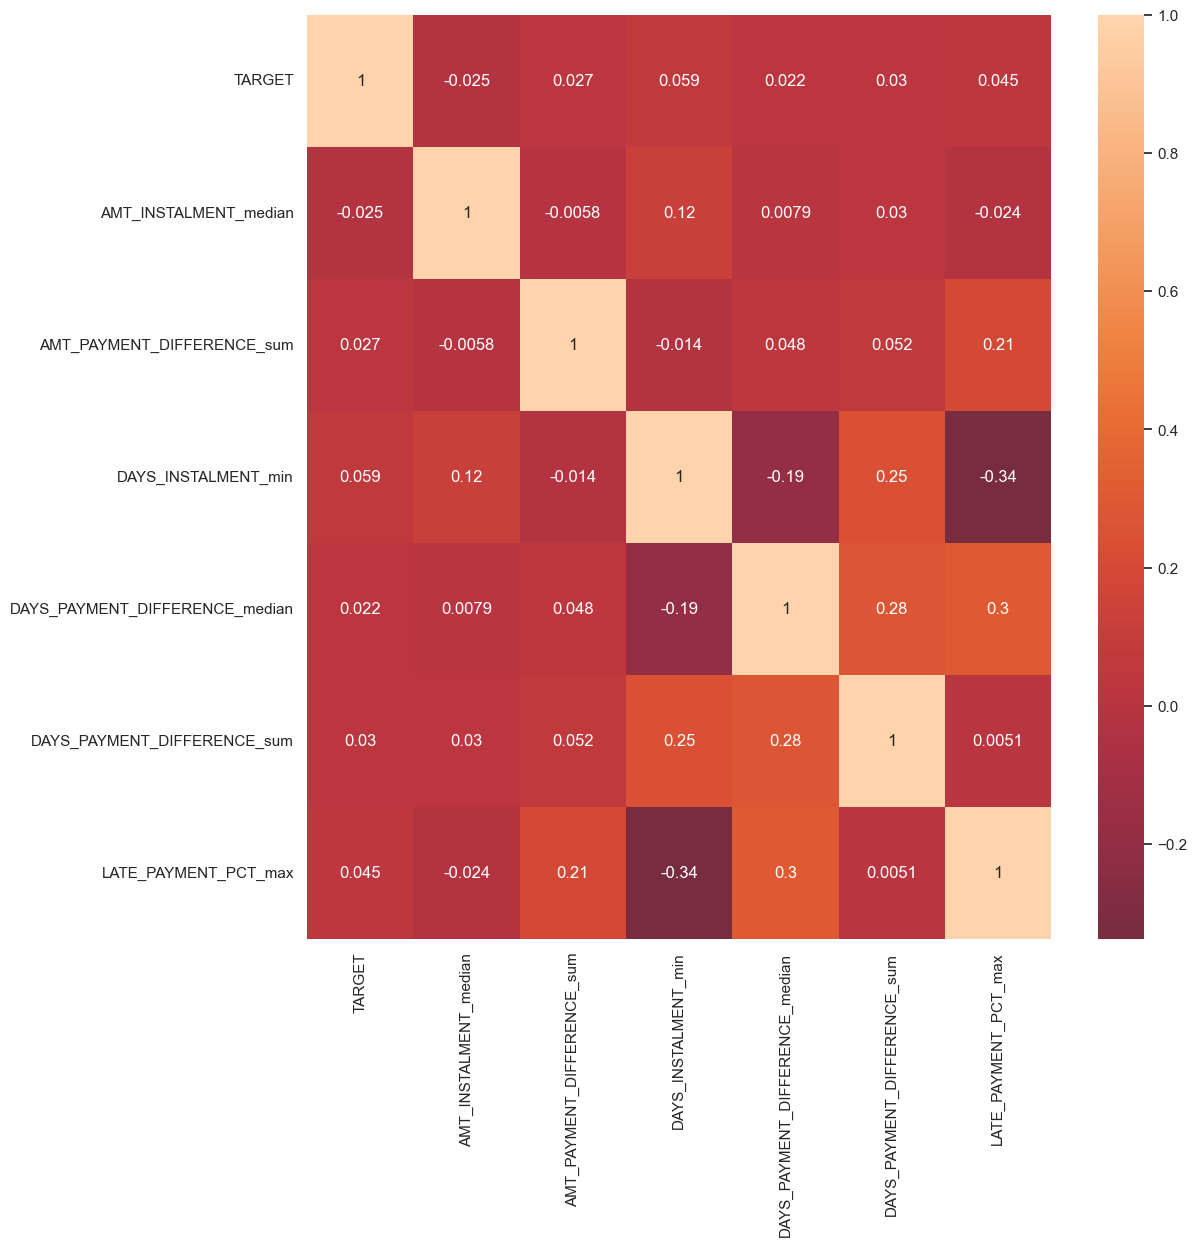

In [138]:
ax=sns.heatmap(numerical_frame.drop(labels=['SK_ID_CURR', 'AMT_INSTALMENT_median_outlier',
                                            'AMT_PAYMENT_DIFFERENCE_sum_outlier'], 
                                    axis=1).corr(), annot=True, center=-1)
ax.get_figure().set_size_inches(w=12, h=12)

In [139]:
numerical_frame.isnull().sum()

SK_ID_CURR                            0
TARGET                                0
AMT_INSTALMENT_median                 0
AMT_PAYMENT_DIFFERENCE_sum            0
DAYS_INSTALMENT_min                   0
DAYS_PAYMENT_DIFFERENCE_median        8
DAYS_PAYMENT_DIFFERENCE_sum           0
LATE_PAYMENT_PCT_max                  0
AMT_INSTALMENT_median_outlier         0
AMT_PAYMENT_DIFFERENCE_sum_outlier    0
dtype: int64

In [140]:
numerical_frame.to_csv('initial_clean_instalments.csv', index=False)